In [1]:
# Install packages
!pip -q install basemap geopandas pyogrio


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 768.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.5/30.5 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 3.7 MB/s eta 0:00:00


In [2]:
# Import tools
import json
import shutil
import zipfile
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path
from IPython.display import display
from mpl_toolkits.basemap import Basemap
from google.colab import files


In [3]:
# Set plot style
plt.rc("text",usetex=False)
plt.rc("font",family="serif")
plt.rc("mathtext",fontset="cm")
plt.rc("font",size=13)
plt.rc("axes",labelsize=14)
plt.rc("xtick",labelsize=11)
plt.rc("ytick",labelsize=11)
plt.rc("legend",fontsize=11)
plt.rc("xtick",top=False,direction="out")
plt.rc("ytick",right=False,direction="out")
plt.rc("xtick.major",size=4.5,width=0.9)
plt.rc("ytick.major",size=4.5,width=0.9)
plt.rc("lines",linewidth=1.8,markersize=4.5,markeredgewidth=0.8)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
colors={"TAPS":"#0072B2","Target weight":"#D55E00","Degree":"#009E73","D-optimal":"#CC79A7","Leverage":"#E69F00","Random":"#7F7F7F","No sensors":"#000000"}


In [4]:
# Define map style
def camap(figsize=(8,7)):
    fig, ax = plt.subplots(figsize=figsize)
    base = Basemap(projection="cyl",llcrnrlat=32.5,urcrnrlat=42.1,llcrnrlon=-124.6,urcrnrlon=-114.0,resolution="l",ax=ax)
    base.drawcoastlines(linewidth=1.0,color="black")
    base.drawcountries(linewidth=1.0,color="black")
    base.drawstates(linewidth=0.8,color="#777777")
    base.fillcontinents(color="#E5E5E5",lake_color="white")
    base.drawmapboundary(fill_color="white",linewidth=0)
    ax.axis("off")
    return fig, ax


In [5]:
# Upload region files
uploaded = files.upload()
assert len(uploaded)==1
archive = list(uploaded.keys())[0]
data = Path("regions_data")
shutil.rmtree(data,ignore_errors=True)
data.mkdir()
with zipfile.ZipFile(archive) as bundle:
    bundle.extractall(data)


Saving 01-regions.zip to 01-regions.zip


In [6]:
# Load region data
meta = pd.read_csv(data/"sites.csv",dtype={"site":str})
target = pd.read_csv(data/"target.csv",dtype={"site":str})
pm = pd.read_csv(data/"pm.csv",index_col=0,parse_dates=True)
smoke = pd.read_csv(data/"smoke.csv",index_col=0,parse_dates=True)
bay = gpd.read_file(data/"bay.geojson")
order = target["site"].tolist()
meta = meta.set_index("site").loc[order].reset_index()
pm = pm[order]
smoke = smoke[order]
weights = meta["weight"].to_numpy()
assert len(meta)==104 and meta["site"].is_unique
assert list(pm.columns)==order and list(smoke.columns)==order
assert np.isclose(weights.sum(),1,atol=1e-10)
assert np.allclose(weights,target["weight"].to_numpy())
print("Stations:",len(meta))
print("Days:",len(pm))
print("Weight sum:",weights.sum())


Stations: 104
Days: 1071
Weight sum: 0.9999999999999991


In [7]:
# Split data and distance
train = pm[pm.index.year<=2022]
valid = pm[pm.index.year==2023]
test = pm[pm.index.year==2024]
corr = train.corr(min_periods=100).fillna(0)
lat = np.radians(meta["lat"].to_numpy())
lon = np.radians(meta["lon"].to_numpy())
dlat = lat[:,None]-lat[None,:]
dlon = lon[:,None]-lon[None,:]
a = np.sin(dlat/2)**2+np.cos(lat[:,None])*np.cos(lat[None,:])*np.sin(dlon/2)**2
dist = 2*6371*np.arcsin(np.sqrt(a))
assert len(train)==765 and len(valid)==153 and len(test)==153
print("Training days:",len(train))
print("Validation days:",len(valid))
print("Testing days:",len(test))


Training days: 765
Validation days: 153
Testing days: 153


In [8]:
# Define graph tools
def graph(k,q):
    n = len(meta)
    mat = np.zeros((n,n))
    cor = np.clip(corr.to_numpy(),0,1)
    near = np.argsort(dist,axis=1)[:,1:k+1]
    scale = dist[np.arange(n),near[:,-1]]
    for i in range(n):
        for j in near[i]:
            value = np.exp(-dist[i,j]**2/(scale[i]*scale[j]))*cor[i,j]**q
            mat[i,j] = max(mat[i,j],value)
            mat[j,i] = max(mat[j,i],value)
    return mat

def score(mat,mask):
    truth = valid.to_numpy()[mask]
    seen = ~np.isnan(truth)
    observed = np.nan_to_num(truth,nan=0)
    top = observed@mat.T
    bottom = seen.astype(float)@mat.T
    pred = np.divide(top,bottom,out=np.zeros_like(top),where=bottom>0)
    use = seen&(bottom>0)
    nrmse = np.sqrt(np.sum((pred[use]-truth[use])**2)/np.sum(truth[use]**2))
    mae = np.mean(np.abs(pred[use]-truth[use]))
    return nrmse,mae


In [9]:
# Select graph parameters
allmask = np.ones(len(valid),dtype=bool)
smokemask = (smoke.loc[valid.index].max(axis=1)>0).to_numpy()
rows = []
for k in [4,5,6,8,10]:
    for q in [0,1,2]:
        mat = graph(k,q)
        net = nx.from_numpy_array(mat)
        degree = mat.sum(axis=1)
        scale = np.diag(1/np.sqrt(degree))
        lap = np.eye(len(mat))-scale@mat@scale
        spectrum = np.linalg.eigvalsh(lap)
        edge = mat[np.triu_indices(len(mat),1)]
        edge = edge[edge>0]
        allnrmse,allmae = score(mat,allmask)
        smokenrmse,smokemae = score(mat,smokemask)
        rows.append({"k":k,"q":q,"parts":nx.number_connected_components(net),"edges":net.number_of_edges(),"minweight":edge.min(),"mindegree":degree.min(),"lambda2":spectrum[1],"weak":(edge<1e-6).sum(),"allnrmse":allnrmse,"allmae":allmae,"smokenrmse":smokenrmse,"smokemae":smokemae})
grid = pd.DataFrame(rows)
pick = grid[grid["parts"]==1].sort_values(["smokenrmse","allnrmse","edges"]).iloc[0]
k = int(pick["k"])
q = int(pick["q"])
W = graph(k,q)
assert k==10 and q==2
display(grid.sort_values(["smokenrmse","allnrmse"]).round(5))
print("Selected k:",k)
print("Selected q:",q)
print("Smoke nRMSE:",round(pick["smokenrmse"],4))
print("Overall nRMSE:",round(pick["allnrmse"],4))


,k,q,parts,edges,minweight,mindegree,lambda2,weak,allnrmse,allmae,smokenrmse,smokemae
14,10,2,1,664,0.00020,0.62770,0.00796,0,0.42232,2.10084,0.43823,2.23195
11,8,2,1,538,0.00015,0.49219,0.00629,0,0.42200,2.06892,0.43824,2.19670
2,4,2,1,278,0.00042,0.11499,0.00180,0,0.42375,2.04333,0.43914,2.14630
8,6,2,1,407,0.00389,0.36739,0.00405,0,0.42464,2.05927,0.44098,2.17850
1,4,1,1,278,0.00149,0.26709,0.00217,0,0.42577,2.06044,0.44128,2.16799
5,5,2,1,345,0.00410,0.20685,0.00254,0,0.42591,2.05701,0.44192,2.16893
10,8,1,1,538,0.00149,0.97453,0.00730,0,0.42796,2.13388,0.44433,2.27374
4,5,1,1,345,0.00890,0.47139,0.00313,0,0.42887,2.08167,0.44497,2.20037
7,6,1,1,407,0.00560,0.76265,0.00495,0,0.42865,2.09766,0.44511,2.22542
0,4,0,1,278,0.00440,0.62346,0.00246,0,0.43004,2.09803,0.44562,2.21299


Selected k: 10
Selected q: 2
Smoke nRMSE: 0.4382
Overall nRMSE: 0.4223


In [10]:
# Analyze graph spectrum
degree = W.sum(axis=1)
L = np.diag(degree)-W
values,vectors = np.linalg.eigh(L)
values = np.maximum(values,0)
edge = W[np.triu_indices(len(W),1)]
edge = edge[edge>0]
check = pd.DataFrame([{"stations":len(meta),"edges":len(edge),"minweight":edge.min(),"medianweight":np.median(edge),"mindegree":degree.min(),"zeros":(values<1e-8).sum(),"lambda2":values[1]}])
assert len(edge)==664 and int((values<1e-8).sum())==1
display(check.round(6))

filled = train.fillna(train.mean()).to_numpy()
coef = filled@vectors
energy = np.sum(coef**2,axis=0)
total = np.cumsum(energy)/energy.sum()
centered = filled-filled.mean(axis=1,keepdims=True)
coef = centered@vectors
energy = np.sum(coef**2,axis=0)
spatial = np.cumsum(energy)/energy.sum()
truth = valid.to_numpy()
filled = valid.fillna(train.mean()).to_numpy()
seen = ~np.isnan(truth)
rows = []
for modes in [10,20,30,40,50,60,70,80]:
    basis = vectors[:,:modes]
    pred = filled@basis@basis.T
    nrmse = np.sqrt(np.sum((pred[seen]-truth[seen])**2)/np.sum(truth[seen]**2))
    rows.append({"modes":modes,"total":total[modes-1],"spatial":spatial[modes-1],"valid":nrmse})
band = pd.DataFrame(rows)
print("Modes for 95% total energy:",np.searchsorted(total,0.95)+1)
print("Modes for 95% spatial energy:",np.searchsorted(spatial,0.95)+1)
display(band.round(4))


,stations,edges,minweight,medianweight,mindegree,zeros,lambda2
0,104,664,0.000202,0.253042,0.627697,1,0.030131


Modes for 95% total energy: 42
Modes for 95% spatial energy: 71


,modes,total,spatial,valid
0,10,0.7594,0.4975,0.3762
1,20,0.8408,0.6676,0.2675
2,30,0.9210,0.8350,0.2157
3,40,0.9472,0.8897,0.1770
4,50,0.9638,0.9244,0.1584
5,60,0.9715,0.9406,0.1441
6,70,0.9758,0.9495,0.1294
7,80,0.9832,0.9649,0.1045


,horizon,time,effective,low,first5,first10
0,0.00,0.0000,12,31,0.7737,0.8816
1,0.25,0.0734,11,20,0.8018,0.9074
2,0.50,0.1467,10,12,0.8239,0.9265
3,1.00,0.2935,9,10,0.8560,0.9510
4,2.00,0.5870,8,8,0.8947,0.9740
5,4.00,1.1740,6,6,0.9368,0.9898


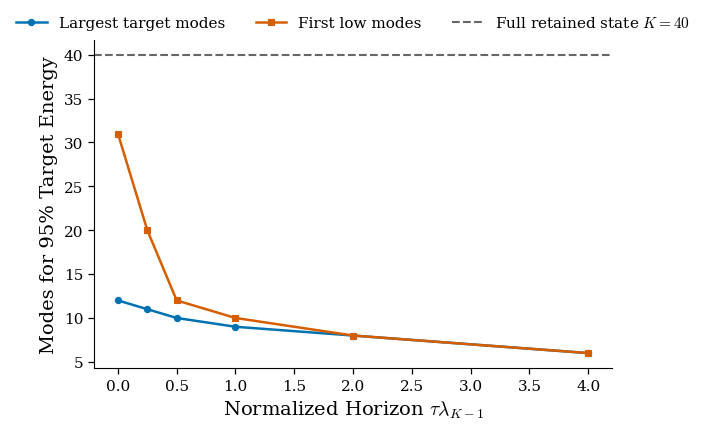

In [11]:
# Measure target dimension
K = 40
basis = vectors[:,:K]
lam = values[:K]
scale = lam[-1]
rows = []
spectra = {}
for horizon in [0,0.25,0.5,1,2,4]:
    tau = horizon/scale
    targetvector = np.exp(-tau*lam)*(basis.T@weights)
    share = targetvector**2/(targetvector@targetvector)
    ranked = np.sort(share)[::-1]
    rows.append({"horizon":horizon,"time":tau,"effective":np.searchsorted(np.cumsum(ranked),0.95)+1,"low":np.searchsorted(np.cumsum(share),0.95)+1,"first5":share[:5].sum(),"first10":share[:10].sum()})
    spectra[horizon] = share
targetdim = pd.DataFrame(rows)
display(targetdim.round(4))

fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(targetdim["horizon"],targetdim["effective"],marker="o",color=colors["TAPS"],label="Largest target modes")
ax.plot(targetdim["horizon"],targetdim["low"],marker="s",color=colors["Target weight"],label="First low modes")
ax.axhline(K,linestyle="--",linewidth=1.5,color="#666666",label=rf"Full retained state $K={K}$")
ax.set_xlabel(r"Normalized Horizon $\tau\lambda_{K-1}$")
ax.set_ylabel("Modes for 95% Target Energy")
ax.legend(loc="lower center",bbox_to_anchor=(0.5,1.01),ncol=3,frameon=False,borderaxespad=0)
plt.tight_layout()
plt.savefig("dimension.png",dpi=300,bbox_inches="tight",facecolor="white")
plt.show()


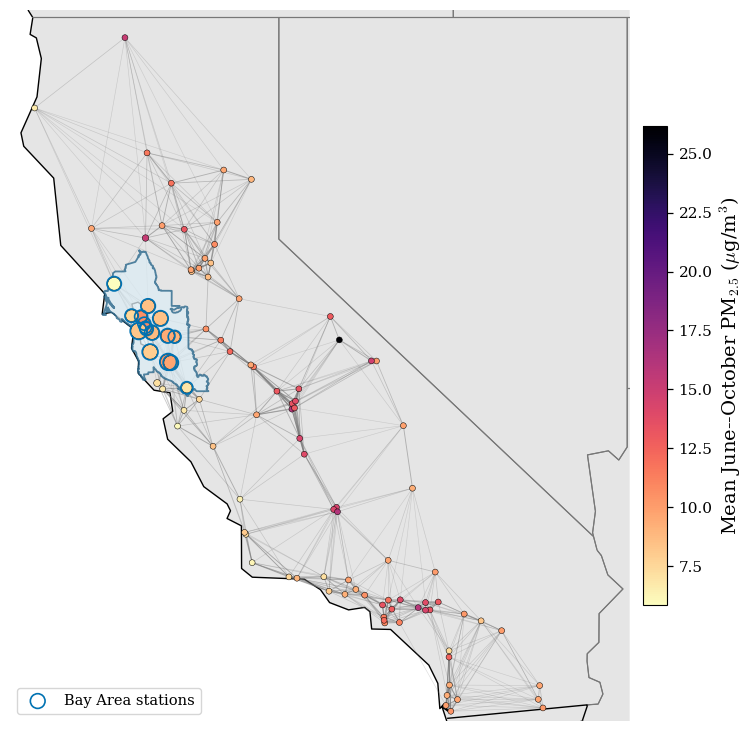

In [12]:
# Map California graph
fig, ax = camap(figsize=(8,7.5))
pairs = np.argwhere(np.triu(W,1)>0)
strength = W[pairs[:,0],pairs[:,1]]
strength = strength/strength.max()
for number,(i,j) in enumerate(pairs):
    ax.plot([meta.loc[i,"lon"],meta.loc[j,"lon"]],[meta.loc[i,"lat"],meta.loc[j,"lat"]],color="#777777",linewidth=0.4+0.5*strength[number],alpha=0.25+0.45*strength[number],zorder=2)
bay.plot(ax=ax,facecolor="#DCECF4",edgecolor="#1F5F85",linewidth=1.3,alpha=0.75,zorder=3)
sizes = 18+280*meta["weight"]**0.5
plot = ax.scatter(meta["lon"],meta["lat"],c=meta["mean"],s=sizes,cmap="magma_r",edgecolors="black",linewidths=0.35,zorder=4)
inside = meta["bay"]==1
ax.scatter(meta.loc[inside,"lon"],meta.loc[inside,"lat"],s=sizes[inside]+22,facecolors="none",edgecolors=colors["TAPS"],linewidths=1.2,label="Bay Area stations",zorder=5)
bar = fig.colorbar(plot,ax=ax,fraction=0.035,pad=0.02)
bar.set_label(r"Mean June--October PM$_{2.5}$ ($\mu$g/m$^3$)")
ax.legend(loc="lower left",frameon=True,fontsize=10.5)
plt.tight_layout()
plt.savefig("graph.png",dpi=300,bbox_inches="tight",facecolor="white")
plt.show()


In [13]:
# Define sensor tools
def case(modes,horizon,clock):
    basis = vectors[:,:modes]
    lam = values[:modes]
    scale = lam[-1]
    times = np.array(clock)/scale
    decay = np.exp(-np.outer(times,lam))
    blocks = [decay*basis[v,:] for v in range(len(meta))]
    info = [block.T@block for block in blocks]
    full = np.sum(info,axis=0)
    beta = 0.01*np.trace(full)/modes
    targetvector = np.exp(-(horizon/scale)*lam)*(basis.T@weights)
    return blocks,info,targetvector,beta

def matrix(selected,blocks):
    return np.vstack([blocks[v] for v in selected])

def span(selected,blocks,targetvector):
    mat = matrix(selected,blocks)
    coef = np.linalg.lstsq(mat.T,targetvector,rcond=None)[0]
    return np.linalg.norm(mat.T@coef-targetvector)/np.linalg.norm(targetvector)

def measure(selected,blocks,targetvector,beta):
    mat = matrix(selected,blocks)
    coef = np.linalg.solve(mat@mat.T+beta*np.eye(mat.shape[0]),mat@targetvector)
    residual = mat.T@coef-targetvector
    mismatch = np.linalg.norm(residual)/np.linalg.norm(targetvector)
    penalty = np.sqrt(beta)*np.linalg.norm(coef)/np.linalg.norm(targetvector)
    return mismatch,penalty,np.sqrt(mismatch**2+penalty**2)

def rank(selected,blocks):
    return np.linalg.matrix_rank(matrix(selected,blocks),tol=1e-9)

def singular(selected,blocks,modes):
    mat = matrix(selected,blocks)
    if mat.shape[0]<modes:
        return 0
    return np.linalg.svd(mat,compute_uv=False)[-1]

def amplify(selected,blocks,targetvector,beta):
    mat = matrix(selected,blocks)
    coef = np.linalg.solve(mat@mat.T+beta*np.eye(mat.shape[0]),mat@targetvector)
    return np.linalg.norm(coef)

def choose(info,targetvector,beta,limit,kind="taps"):
    order = []
    current = beta*np.eye(len(targetvector))
    for step in range(limit):
        candidates = [v for v in range(len(meta)) if v not in order]
        scores = []
        for v in candidates:
            trial = current+info[v]
            value = beta*targetvector@np.linalg.solve(trial,targetvector) if kind=="taps" else -np.linalg.slogdet(trial)[1]
            scores.append(value)
        best = candidates[np.argmin(scores)]
        order.append(best)
        current = current+info[best]
    return order

def exactbudget(order,blocks,targetvector,limit=40,tol=1e-6):
    for count in range(1,limit+1):
        if span(order[:count],blocks,targetvector)<=tol:
            return count
    return np.nan


In [14]:
# Build sensor orders
blocks,info,g,beta = case(K,1,[0,0.25,0.5])
full = np.sum(info,axis=0)
taps = choose(info,g,beta,40,"taps")
dopt = choose(info,g,beta,40,"dopt")
degreeorder = list(np.argsort(-W.sum(axis=1))[:40])
weightorder = list(np.argsort(-weights)[:40])
base = full+beta*np.eye(K)
leverage = [np.trace(block@np.linalg.solve(base,block.T)) for block in blocks]
leverageorder = list(np.argsort(-np.array(leverage))[:40])
methods = {"TAPS":taps,"D-optimal":dopt,"Leverage":leverageorder,"Degree":degreeorder,"Target weight":weightorder}
print("TAPS:",meta.loc[taps[:10],"site"].tolist())
print("D-optimal:",meta.loc[dopt[:10],"site"].tolist())
print("Regularization:",round(beta,6))


TAPS: ['06-001-0009', '06-097-0004', '06-081-1001', '06-053-0002', '06-001-0015', '06-013-0002', '06-001-0007', '06-075-0005', '06-001-0012', '06-085-0006']
D-optimal: ['06-027-1023', '06-029-0018', '06-025-1003', '06-093-2001', '06-063-1010', '06-065-1016', '06-073-1201', '06-023-1004', '06-087-1005', '06-071-0306']
Regularization: 0.024502


In [15]:
# Build recovery tables
rows = []
for name,order in methods.items():
    for count in range(1,41):
        selected = order[:count]
        mismatch,penalty,totalrisk = measure(selected,blocks,g,beta)
        sigma = singular(selected,blocks,K)
        rows.append({"method":name,"sensors":count,"span":span(selected,blocks,g),"mismatch":mismatch,"penalty":penalty,"risk":totalrisk,"norm":amplify(selected,blocks,g,beta),"sigma":sigma,"full":np.sqrt(beta/(sigma**2+beta)),"rank":rank(selected,blocks)})
curve = pd.DataFrame(rows)
rows = []
for name in methods:
    valueset = curve[curve["method"]==name]
    exact = valueset[valueset["span"]<=1e-6]
    fullrank = valueset[valueset["rank"]==K]
    rows.append({"method":name,"exact":exact["sensors"].iloc[0] if len(exact) else np.nan,"rank":exact["rank"].iloc[0] if len(exact) else np.nan,"fullrank":fullrank["sensors"].iloc[0] if len(fullrank) else np.nan})
budgets = pd.DataFrame(rows)
display(budgets)
display(curve[curve["sensors"].isin([5,10,14,20,40])].round(5))


,method,exact,rank,fullrank
0,TAPS,10,28,NaN
1,D-optimal,14,40,14.0
2,Leverage,14,39,15.0
3,Degree,11,32,22.0
4,Target weight,10,28,25.0


,method,sensors,span,mismatch,penalty,risk,norm,sigma,full,rank
4,TAPS,5,0.00150,0.07893,0.19491,0.21028,0.27761,0.00000,1.00000,15
9,TAPS,10,0.00000,0.04399,0.12541,0.13290,0.17862,0.00000,1.00000,28
13,TAPS,14,0.00000,0.03982,0.10574,0.11299,0.15061,0.00000,1.00000,30
19,TAPS,20,0.00000,0.01798,0.09250,0.09424,0.13176,0.00000,1.00000,33
39,TAPS,40,0.00000,0.00842,0.09109,0.09148,0.12975,0.00000,1.00000,38
44,D-optimal,5,0.99922,1.00000,0.00140,1.00000,0.00200,0.00000,1.00000,15
49,D-optimal,10,0.62581,0.98032,0.12683,0.98849,0.18064,0.00000,1.00000,30
53,D-optimal,14,0.00000,0.97839,0.13293,0.98738,0.18934,0.00000,1.00000,40
59,D-optimal,20,0.00000,0.85486,0.30283,0.90692,0.43133,0.00034,1.00000,40
79,D-optimal,40,0.00000,0.07727,0.26178,0.27294,0.37286,0.52312,0.28667,40


In [16]:
# Verify risk formulas
def verify(order,count,name):
    selected = order[:count]
    mat = matrix(selected,blocks)
    coef = np.linalg.solve(mat@mat.T+beta*np.eye(mat.shape[0]),mat@g)
    residual = mat.T@coef-g
    direct = np.sqrt((residual@residual+beta*(coef@coef))/(g@g))
    _,sing,right = np.linalg.svd(mat,full_matrices=True)
    singulars = np.zeros(K)
    singulars[:len(sing)] = sing
    modes = right@g
    svd = np.sqrt(np.sum(modes**2*beta/(singulars**2+beta))/(g@g))
    exact = np.linalg.lstsq(mat.T,g,rcond=None)[0]
    return {"method":name,"sensors":count,"rank":np.sum(sing>1e-9),"sigma":singulars[-1],"closed":measure(selected,blocks,g,beta)[2],"direct":direct,"svd":svd,"residual":np.linalg.norm(mat.T@exact-g)/np.linalg.norm(g),"exactnorm":np.linalg.norm(exact)}

checks = pd.DataFrame([verify(taps,10,"TAPS"),verify(weightorder,10,"Target weight"),verify(dopt,14,"D-optimal"),verify(dopt,40,"D-optimal")])
assert np.allclose(checks["closed"],checks["direct"],rtol=1e-10,atol=1e-12)
assert np.allclose(checks["closed"],checks["svd"],rtol=1e-10,atol=1e-12)
display(checks.round(8))


,method,sensors,rank,sigma,closed,direct,svd,residual,exactnorm
0,TAPS,10,28,0.000000,0.132899,0.132899,0.132899,7.000000e-08,812.780931
1,Target weight,10,28,0.000000,0.152059,0.152059,0.152059,2.000000e-07,36534.017353
2,D-optimal,14,40,0.000005,0.987380,0.987380,0.987380,0.000000e+00,658.665997
3,D-optimal,40,40,0.523125,0.272944,0.272944,0.272944,0.000000e+00,0.405365


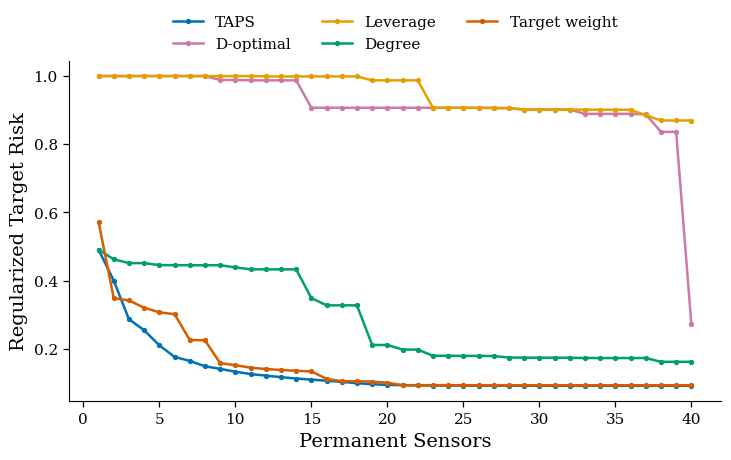

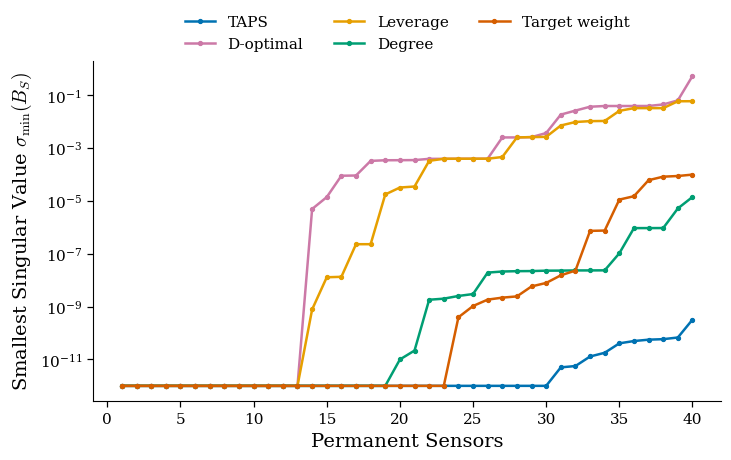

In [17]:
# Plot risk and conditioning
fig, ax = plt.subplots(figsize=(7.5,4.8))
for name in methods:
    valueset = curve[curve["method"]==name]
    ax.plot(valueset["sensors"],valueset["risk"],marker="o",markersize=3,color=colors[name],label=name)
ax.set_xlabel("Permanent Sensors")
ax.set_ylabel("Regularized Target Risk")
ax.legend(loc="lower center",bbox_to_anchor=(0.5,1.01),ncol=3,frameon=False,borderaxespad=0)
plt.tight_layout()
plt.savefig("risk.png",dpi=300,bbox_inches="tight",facecolor="white")
plt.show()

fig, ax = plt.subplots(figsize=(7.5,4.8))
for name in methods:
    valueset = curve[curve["method"]==name]
    ax.semilogy(valueset["sensors"],np.maximum(valueset["sigma"],1e-12),marker="o",markersize=3,color=colors[name],label=name)
ax.set_xlabel("Permanent Sensors")
ax.set_ylabel(r"Smallest Singular Value $\sigma_{\min}(B_S)$")
ax.legend(loc="lower center",bbox_to_anchor=(0.5,1.01),ncol=3,frameon=False,borderaxespad=0)
plt.tight_layout()
plt.savefig("singular.png",dpi=300,bbox_inches="tight",facecolor="white")
plt.show()


In [18]:
# Compare ten sensors
rng = np.random.default_rng(7)
rows = []
for trial in range(100):
    selected = rng.choice(len(meta),10,replace=False).tolist()
    mismatch,penalty,totalrisk = measure(selected,blocks,g,beta)
    rows.append({"trial":trial,"mismatch":mismatch,"penalty":penalty,"risk":totalrisk})
random = pd.DataFrame(rows)
rows = []
for name,order in methods.items():
    mismatch,penalty,totalrisk = measure(order[:10],blocks,g,beta)
    rows.append({"method":name,"mismatch":mismatch,"penalty":penalty,"risk":totalrisk})
rows.append({"method":"Random","mismatch":random["mismatch"].mean(),"penalty":random["penalty"].mean(),"risk":random["risk"].mean()})
rows.append({"method":"No sensors","mismatch":1.0,"penalty":0.0,"risk":1.0})
compare = pd.DataFrame(rows).sort_values("mismatch")
allset = list(range(len(meta)))
mismatch,penalty,totalrisk = measure(allset,blocks,g,beta)
reference = pd.DataFrame([{"method":"All 104 sensors","sensors":len(meta),"mismatch":mismatch,"penalty":penalty,"risk":totalrisk,"rank":rank(allset,blocks),"sigma":singular(allset,blocks,K)}])
tapsvalue = compare.loc[compare["method"]=="TAPS","mismatch"].iloc[0]
weightvalue = compare.loc[compare["method"]=="Target weight","mismatch"].iloc[0]
randomvalue = compare.loc[compare["method"]=="Random","mismatch"].iloc[0]
fullvalue = reference["mismatch"].iloc[0]
summary = pd.DataFrame([{"metric":"Sensor reduction","value":1-10/len(meta)},{"metric":"Full improvement retained","value":(1-tapsvalue)/(1-fullvalue)},{"metric":"Gain over target weight","value":1-tapsvalue/weightvalue},{"metric":"Gain over random","value":1-tapsvalue/randomvalue},{"metric":"Random sets matched","value":(random["mismatch"]<=tapsvalue).sum()}])
display(compare.round(5))
display(reference.round(5))
display(summary.round(4))


,method,mismatch,penalty,risk
0,TAPS,0.04399,0.12541,0.13290
4,Target weight,0.08062,0.12893,0.15206
3,Degree,0.38710,0.20661,0.43879
5,Random,0.53758,0.21430,0.59959
1,D-optimal,0.98032,0.12683,0.98849
2,Leverage,0.99995,0.00674,0.99997
6,No sensors,1.00000,0.00000,1.00000


,method,sensors,mismatch,penalty,risk,rank,sigma
0,All 104 sensors,104,0.00838,0.09108,0.09146,40,1.40514


,metric,value
0,Sensor reduction,0.9038
1,Full improvement retained,0.9641
2,Gain over target weight,0.4544
3,Gain over random,0.9182
4,Random sets matched,0.0000


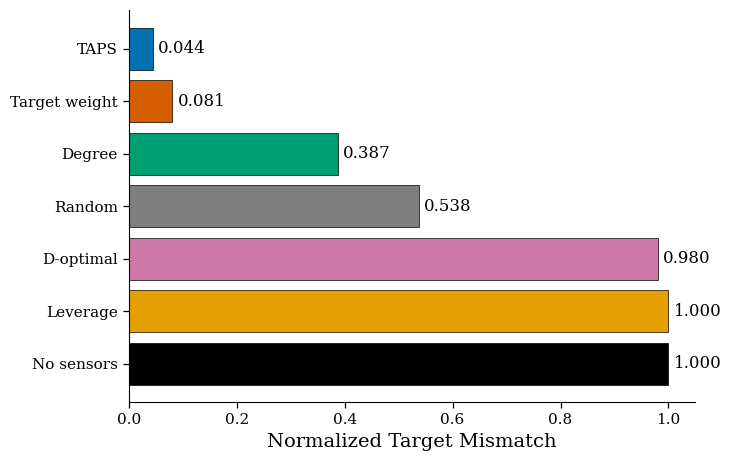

In [19]:
# Plot baseline comparison
chart = compare.sort_values("mismatch",ascending=False)
fig, ax = plt.subplots(figsize=(7.5,4.8))
ax.barh(chart["method"],chart["mismatch"],color=[colors[name] for name in chart["method"]],edgecolor="black",linewidth=0.5)
ax.set_xlabel("Normalized Target Mismatch")
for i,value in enumerate(chart["mismatch"]):
    ax.text(value+0.01,i,f"{value:.3f}",va="center",fontsize=12)
plt.tight_layout()
plt.savefig("baselines.png",dpi=300,bbox_inches="tight",facecolor="white")
plt.show()


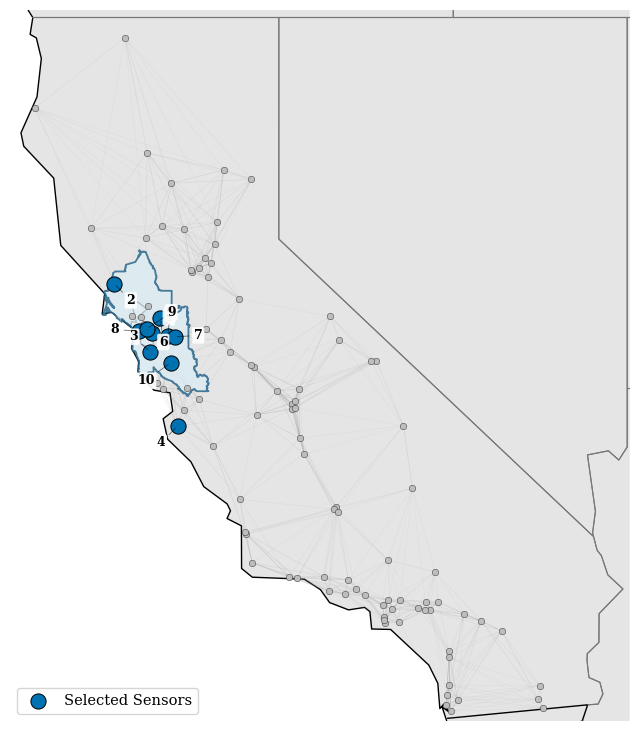

In [20]:
# Map selected sensors
selected = taps[:10]
fig, ax = camap(figsize=(8,7.5))
pairs = np.argwhere(np.triu(W,1)>0)
strength = W[pairs[:,0],pairs[:,1]]
strength = strength/strength.max()
for number,(i,j) in enumerate(pairs):
    ax.plot([meta.loc[i,"lon"],meta.loc[j,"lon"]],[meta.loc[i,"lat"],meta.loc[j,"lat"]],color="#999999",linewidth=0.3+0.35*strength[number],alpha=0.12+0.2*strength[number],zorder=2)
bay.plot(ax=ax,facecolor="#DCECF4",edgecolor="#1F5F85",linewidth=1.3,alpha=0.8,zorder=3)
ax.scatter(meta["lon"],meta["lat"],s=22,color="#BDBDBD",edgecolors="black",linewidths=0.25,zorder=4)
chosen = meta.loc[selected].copy()
ax.scatter(chosen["lon"],chosen["lat"],s=120,color=colors["TAPS"],edgecolors="black",linewidths=0.7,label="Selected Sensors",zorder=5)
offsets=[(12,11),(12,-12),(-12,11),(-12,-12),(2,16),(2,-17),(17,1),(-17,1),(18,12),(-18,-13)]
for number,((_,row),(dx,dy)) in enumerate(zip(chosen.iterrows(),offsets),start=1):
    ax.annotate(str(number),xy=(row["lon"],row["lat"]),xytext=(dx,dy),textcoords="offset points",ha="center",va="center",fontsize=9,fontweight="bold",bbox=dict(boxstyle="round,pad=0.14",facecolor="white",edgecolor="none",alpha=0.9),arrowprops=dict(arrowstyle="-",linewidth=0.5,color="black",alpha=0.65),zorder=6)
ax.legend(loc="lower left",frameon=True,fontsize=10.5)
plt.tight_layout()
plt.savefig("selected.png",dpi=300,bbox_inches="tight",facecolor="white")
plt.show()


In [21]:
# Test model sensitivity
rng = np.random.default_rng(7)
rows = []
for modes in [20,30,40,50]:
    for horizon in [0.5,1,2]:
        trialblocks,trialinfo,trialg,trialbeta = case(modes,horizon,[0,0.25,0.5])
        order = choose(trialinfo,trialg,trialbeta,20,"taps")
        exact = exactbudget(order,trialblocks,trialg,limit=20)
        tapsm = measure(order[:10],trialblocks,trialg,trialbeta)[0]
        weightm = measure(weightorder[:10],trialblocks,trialg,trialbeta)[0]
        degreem = measure(degreeorder[:10],trialblocks,trialg,trialbeta)[0]
        randomm = []
        for run in range(50):
            sample = rng.choice(len(meta),10,replace=False).tolist()
            randomm.append(measure(sample,trialblocks,trialg,trialbeta)[0])
        mismatch,penalty,totalrisk = measure(order[:10],trialblocks,trialg,trialbeta)
        rows.append({"modes":modes,"horizon":horizon,"mismatch":mismatch,"penalty":penalty,"risk":totalrisk,"rank":rank(order[:10],trialblocks),"exact":exact,"bound":int(np.ceil(modes/3)),"taps":tapsm,"weight":weightm,"degree":degreem,"random":np.mean(randomm),"gain":1-tapsm/np.mean(randomm)})
sens = pd.DataFrame(rows)
display(sens.round(4))


,modes,horizon,mismatch,penalty,risk,rank,exact,bound,taps,weight,degree,random,gain
0,20,0.5,0.0233,0.1258,0.1280,18,6,7,0.0233,0.0250,0.2340,0.3236,0.9281
1,20,1.0,0.0394,0.1309,0.1367,19,6,7,0.0394,0.0503,0.2756,0.4159,0.9053
2,20,2.0,0.0589,0.1421,0.1538,19,7,7,0.0589,0.1073,0.3395,0.3231,0.8177
3,30,0.5,0.0239,0.1239,0.1262,24,8,10,0.0239,0.0240,0.2422,0.3207,0.9255
4,30,1.0,0.0402,0.1273,0.1334,24,8,10,0.0402,0.0433,0.2734,0.4715,0.9148
5,30,2.0,0.0504,0.1416,0.1503,25,9,10,0.0504,0.0840,0.3275,0.4575,0.8899
6,40,0.5,0.0369,0.1220,0.1274,26,10,14,0.0369,0.0419,0.3832,0.5018,0.9265
7,40,1.0,0.0440,0.1254,0.1329,28,10,14,0.0440,0.0806,0.3871,0.5298,0.9170
8,40,2.0,0.0474,0.1389,0.1467,28,12,14,0.0474,0.1378,0.4089,0.4789,0.9009
9,50,0.5,0.0352,0.1201,0.1251,27,12,17,0.0352,0.0372,0.3987,0.5861,0.9400


,reads,exact,bound,mismatch,risk,rank
0,1,33,40,0.0599,0.1492,10
1,2,15,20,0.0441,0.1336,20
2,3,10,14,0.0440,0.1329,28
3,4,8,10,0.0439,0.1327,30
4,5,7,8,0.0439,0.1325,30


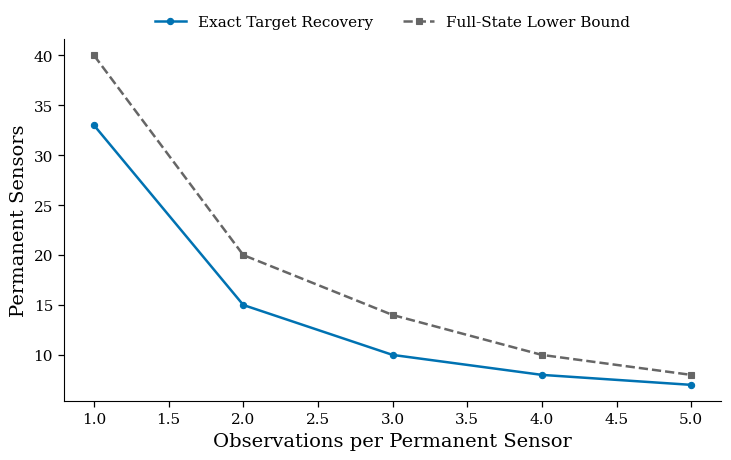

In [22]:
# Test repeated observations
rows = []
for reads in [1,2,3,4,5]:
    clock = np.linspace(0,0.5,reads)
    trialblocks,trialinfo,trialg,trialbeta = case(40,1,clock)
    order = choose(trialinfo,trialg,trialbeta,40,"taps")
    exact = exactbudget(order,trialblocks,trialg)
    mismatch,penalty,totalrisk = measure(order[:10],trialblocks,trialg,trialbeta)
    rows.append({"reads":reads,"exact":exact,"bound":int(np.ceil(40/reads)),"mismatch":mismatch,"risk":totalrisk,"rank":rank(order[:10],trialblocks)})
observe = pd.DataFrame(rows)
display(observe.round(4))

fig, ax = plt.subplots(figsize=(7.5,4.8))
ax.plot(observe["reads"],observe["exact"],marker="o",color=colors["TAPS"],label="Exact Target Recovery")
ax.plot(observe["reads"],observe["bound"],marker="s",linestyle="--",color="#666666",label="Full-State Lower Bound")
ax.set_xlabel("Observations per Permanent Sensor")
ax.set_ylabel("Permanent Sensors")
ax.legend(loc="lower center",bbox_to_anchor=(0.5,1.01),ncol=2,frameon=False,borderaxespad=0)
plt.tight_layout()
plt.savefig("observations.png",dpi=300,bbox_inches="tight",facecolor="white")
plt.show()


In [23]:
# Test observation spacing
rows = []
for window in [0.1,0.25,0.5,0.75]:
    clock = np.linspace(0,window,3)
    trialblocks,trialinfo,trialg,trialbeta = case(40,1,clock)
    order = choose(trialinfo,trialg,trialbeta,40,"taps")
    exact = exactbudget(order,trialblocks,trialg)
    mismatch,penalty,totalrisk = measure(order[:10],trialblocks,trialg,trialbeta)
    rows.append({"window":window,"gap":window/2,"exact":exact,"mismatch":mismatch,"risk":totalrisk,"rank":rank(order[:10],trialblocks)})
spacing = pd.DataFrame(rows)
display(spacing.round(4))


,window,gap,exact,mismatch,risk,rank
0,0.10,0.050,10,0.0565,0.1454,27
1,0.25,0.125,10,0.0515,0.1402,27
2,0.50,0.250,10,0.0440,0.1329,28
3,0.75,0.375,9,0.0431,0.1281,27


In [24]:
# Save graph results
output = Path("results")
shutil.rmtree(output,ignore_errors=True)
output.mkdir()
meta.to_csv(output/"nodes.csv",index=False)
pairs = np.argwhere(np.triu(W,1)>0)
edges = pd.DataFrame({"source":[meta.loc[i,"site"] for i,j in pairs],"target":[meta.loc[j,"site"] for i,j in pairs],"weight":[W[i,j] for i,j in pairs]})
edges.to_csv(output/"edges.csv",index=False)
orders = pd.DataFrame({"order":range(1,41),"taps":[meta.loc[v,"site"] for v in taps],"dopt":[meta.loc[v,"site"] for v in dopt],"leverage":[meta.loc[v,"site"] for v in leverageorder],"degree":[meta.loc[v,"site"] for v in degreeorder],"weight":[meta.loc[v,"site"] for v in weightorder]})
orders.to_csv(output/"orders.csv",index=False)
chosen = meta.loc[taps[:10],["site","lat","lon","weight","bay"]].copy()
chosen.insert(0,"order",range(1,11))
chosen.to_csv(output/"selected.csv",index=False)
grid.to_csv(output/"graph_selection.csv",index=False)
band.to_csv(output/"bandwidth.csv",index=False)
targetdim.to_csv(output/"target_dimension.csv",index=False)
checks.to_csv(output/"risk_checks.csv",index=False)
random.to_csv(output/"random_trials.csv",index=False)
budgets.to_csv(output/"budgets.csv",index=False)
curve.to_csv(output/"curves.csv",index=False)
compare.to_csv(output/"baselines.csv",index=False)
reference.to_csv(output/"reference.csv",index=False)
sens.to_csv(output/"sensitivity.csv",index=False)
observe.to_csv(output/"observations.csv",index=False)
spacing.to_csv(output/"spacing.csv",index=False)
summary.to_csv(output/"summary.csv",index=False)
params = {"stations":len(meta),"edges":len(edges),"neighbors":k,"power":q,"modes":K,"times":[0,0.25,0.5],"horizon":1,"beta":float(beta),"budget":10,"seed":7,"trials":100,"tolerance":1e-6,"rank_tolerance":1e-9}
with open(output/"parameters.json","w") as file:
    json.dump(params,file,indent=2)
figures = ["graph.png","dimension.png","risk.png","singular.png","baselines.png","selected.png","observations.png"]
for name in figures:
    shutil.copy(name,output/name)
manifest = {"input":"regions.zip from 01-regions.ipynb","figures":figures,"tables":sorted(path.name for path in output.glob("*.csv"))}
with open(output/"manifest.json","w") as file:
    json.dump(manifest,file,indent=2)
archive = shutil.make_archive("graphs","zip",output)
print("Saved:",archive)
print("Files:",len(list(output.iterdir())))
files.download(archive)


Saved: /content/graphs.zip
Files: 26


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>